# Quick start tutorial: SUITPy for fMRI analysis
This tutorial is a minimal example of how to use SUITPy to perform a group fMRI analysis for the cerebellum. 
It involves the following steps:

* Isolate the cerebellum
* Normalize the anatomical to SUIT space
* Reslice the contrast maps into SUIT space
* Visualizing the results on the flat map
* Summarizing the results using atlas ROI.

To start you need:
* An anatomical T1-weighted image of each subject (``sub-ex_T1w.nii.gz``)
* The functional map(s) for each subject **coregistered** to the anatomical image (``sub-ex_contrast.nii.gz``)

We recommend using a minimal processing pipeline, including only correction for spatial distortions, motion correction, and co-registration to the anatomical image. The first-level GLM is best calculated in the native space of the subject - normalization to MNI space or any smoothing is best avoided at this point.

*Note: It is of course possible to apply the pipeline to MNI-normalized data, as long as both individual T1-images and functional maps are in MNI space. Smoothing should be avoided, however to prevent bleeding of cortical activity into the cerebellum.*

*Note: You can find additional details and explanations for each step in the corresponding sections of the documentation.*


## Getting setup 
Install SUITPy

`pip install SUITPy`

For detailed instructions and dependencies, see `Installation`.

In [13]:
# Import necessary packages
from nilearn import plotting
import SUITPy as suit
import nibabel as nib
import ants
import nilearn.plotting as  npl
import matplotlib.pyplot as plt


## 1. Isolate the cerebellum
The first step is use ``isolate`` to create a cerebellum–brainstem mask from the anatomical image. The mask is required for normalization and helps avoid signal spillover from nearby cortex.

In [3]:
# This function generates isolation mask for the cerebellum based on a T1 scan
suit.isolate('sub-ex_T1w.nii.gz')

preprocessing
isolating cerebellum using UNet model
postprocessing
saving results into /Users/jdiedrichsen/Python/SUITPy/docs/source/tutorials


 The mask is saved as ``sub-ex_T1w_cerebellum_dseg.nii.gz`` in the same folder as the anatomical scan.

 Although the isolation algorithm works very reliably and usually does not require and correction, it is good practice to check the mask.  

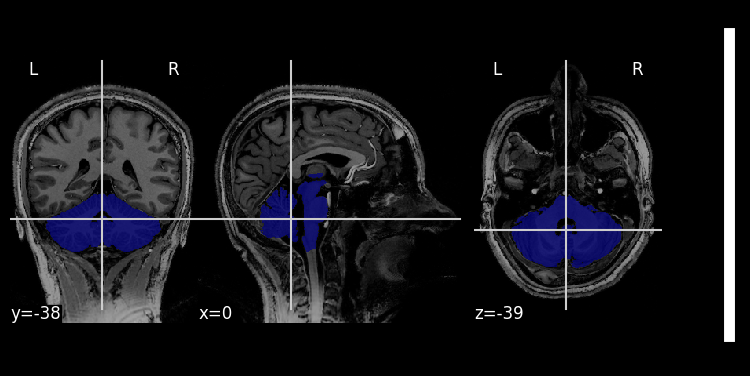

In [5]:
# Visualize the mask on the T1 image
img = nib.load('sub-ex_T1w.nii.gz')
mask = nib.load('sub-ex_T1w_cerebellum_dseg.nii.gz')
plotting.plot_roi(mask,img)

## 2. Normalize the cerebellum to the SUIT template
The SUIT normalization module estimates a deformation field that aligns an individual’s cerebellum to the SUIT template, using the isolation mask from the previous step. In SUITPy, this procedure is implemented with ANTsPy. The resulting deformation can then be applied to reslice anatomical or functional data into SUIT space.

In the simplest usage, normalize requires only the subject’s T1-weighted image and the isolation mask.

In [ ]:
# This function normalizes a source image to the SUIT cerebellar template using a provided cerebellum
suit.normalize(source_file = 'sub-ex_T1w.nii.gz',mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz')

Normalizing sub-ex_T1w to /Users/jdiedrichsen/Python/SUITPy/SUITPy/templates/tpl-SUIT_T1w.nii.gz
Saving the normalized image into /Users/jdiedrichsen/Python/SUITPy/docs/source/tutorials/sub-ex_T1w_space-SUIT.nii.gz
Saving deformation field into /Users/jdiedrichsen/Python/SUITPy/docs/source/tutorials/sub-ex_T1w_to-SUIT_mode-image_xfm.nii.gz


This step generates two outputs: 

* the normalized image ``sub-ex_T1w_space-SUIT.nii.gz``.
* the deformation field ``sub-ex_T1w_to-SUIT_model-image_xfm.nii.gz``.

(for more options, see the `normalize` documentation).

Again, while the normalization usually works well without manual intervention, it is good practice to check the results.

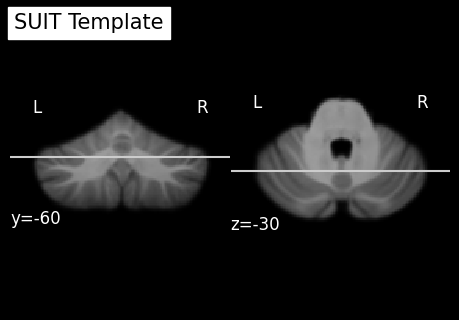

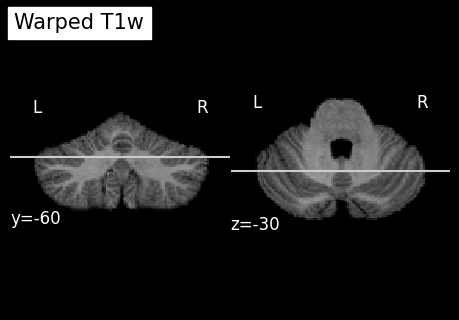

In [16]:
# Load as NiBabel image
norm_img = nib.load('sub-ex_T1w_space-SUIT.nii.gz')
# Load SUIT template
template_img = nib.load('../../../SUITPy/templates/tpl-SUIT_T1w.nii.gz')
# Visualize the result
npl.plot_anat(template_img, title="SUIT Template",display_mode='yz',cut_coords=(-60, -30),colorbar=False)
npl.plot_anat(norm_img, title="Warped T1w",display_mode='yz',cut_coords=(-60, -30),colorbar=False)


## 3. Reslice functional contrasts into SUIT space
In the next step, we want to apply the deformation to the data. You need to apply the anatomical image as source image, deformation file that generated from previous step, and the mask of anatomical image.


In [17]:
# Apply the reslice function
src = 'sub-ex_task-fingerseq.nii.gz'
deform = 'sub-ex_T1w_to-SUIT_mode-image_xfm.nii.gz'
mask = 'sub-ex_T1w_cerebellum_dseg.nii.gz'
img = suit.reslice_image(source_image = src,deformation = deform,mask = mask,voxelsize=2)
nib.save(img,'sub-ex_task-fingerseq_space-SUIT.nii.gz')


## 4. Conduct group-analysis in SUIT space

REWRITE.... JOERN

Once individual subjects have been isolated and normalized to SUIT space, group-level analyses can be carried out using any statistical framework (e.g., **FSL, SPM, .etc**). SUITPy’s role is to ensure that all cerebellar data are aligned to a common high-resolution template, so the group analysis itself is not restricted to a specific package.

In practice, group analysis in SUIT space typically involves:

* Normalizing each subject’s functional or statistical map (e.g., contrast estimate, t-map, beta map) into SUIT space using SUITPy’s normalization pipeline.

* Reslicing all subjects’ data to the same SUIT template grid using suit_reslice.

* Stacking the normalized volumes across subjects into a single subject list.

* Applying your preferred group-level model, such as:

  * one-sample / paired / independent-samples t-tests

  * GLMs with covariates (age, behavior, performance, etc.)

  * mixed-effects models for multi-session datasets

* Correcting for multiple comparisons (FDR, cluster-based correction, threshold-free cluster enhancement, etc.).

* Visualising the group results on the SUIT flatmap using suit_flatmap.plot_map.

SUITPy standardizes the cerebellar space and provides high-quality flatmaps; the statistical analysis itself can be performed with whichever neuroimaging or statistical tools best fit your pipeline.

## 5. Visualize on the flatmap

The function here assumes that the data is mapped to SUIT space.you can specify the normalization space with the optional input argument. Please refer to `Flatmap Module` documentation section.

To plot the mapped data, you can use the function `flatmap.plot`, as below:

<Axes: >

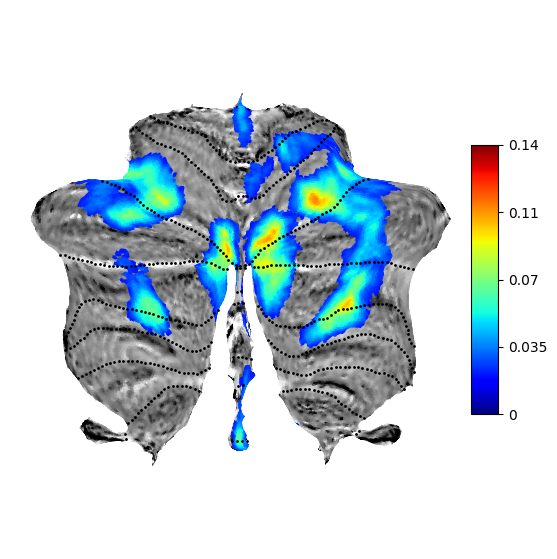

In [21]:
funcdata = flatmap.vol_to_surf('MDTB08_Math.nii',space='SUIT')

# Visualize the flatmap output
flatmap.plot(data=funcdata, cmap='jet', \
    cscale = [0,0.14], \
    threshold=0.02, \
    new_figure=True, \
    colorbar=True, \
    render='matplotlib')

## 6. Get Atlas and summarize

This function uses cerebellar ROIs from an atlas image to summarize cerebellar data. It computes summary values (e.g., mean, std) inside each atlas region and returns the results as a `pandas.DataFrame`.  As you can see, you need to declare the atlas, atlas maps, and space. Moreover, you can use your custom ROI.

In [4]:
image_file = 'sub-02_T1w_space-SUIT.nii.gz'

df = summarize_data(
    images=[image_file],
    atlas="Buckner_2011",
    maps="atl-Buckner7",
    space="SUIT",
    stats=("mean", "std", "abs"),
    outfilename=None)

print(df.head())

   image                    image_name  \
0      1  sub-02_T1w_space-SUIT.nii.gz   
1      1  sub-02_T1w_space-SUIT.nii.gz   
2      1  sub-02_T1w_space-SUIT.nii.gz   
3      1  sub-02_T1w_space-SUIT.nii.gz   
4      1  sub-02_T1w_space-SUIT.nii.gz   

                                               atlas           map space  \
0  /content/drive/MyDrive/cerebellar_atlases/Buck...  atl-Buckner7  SUIT   
1  /content/drive/MyDrive/cerebellar_atlases/Buck...  atl-Buckner7  SUIT   
2  /content/drive/MyDrive/cerebellar_atlases/Buck...  atl-Buckner7  SUIT   
3  /content/drive/MyDrive/cerebellar_atlases/Buck...  atl-Buckner7  SUIT   
4  /content/drive/MyDrive/cerebellar_atlases/Buck...  atl-Buckner7  SUIT   

   region                                         regionname     size  \
0       1  0.47058823529411764 0.07058823529411765 0.5254...    619.0   
1       2  0.27450980392156865 0.5098039215686274 0.70588...  28132.0   
2       3  0.0 0.4627450980392157 0.054901960784313725 Ne...  12086.0  